## Replication of the makemore package made by Andrej Karpathy from scratch
Again here the goated video series by Andrej: https://youtube.com/playlist?list=PLAqhIrjkxbuWI23v9cThsA9GvCAUhRvKZ&si=BX4ZweIp7YkWDsze

This notebook mainly serves the purpose of building and improving my own understanding of ai language models. Therefore it will include a lot of markdown sections with my unpolished comments and notes that serve my personal learning. In case you are intersted in the code I recommend visiting Andrej's repo: https://github.com/karpathy/makemore

Loading and inspecting our highly sophisticated training dataset:

In [1]:
words = open('names.txt', 'r').read().splitlines()

In [2]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [3]:
len(words)

32033

In [4]:
min(len(w) for w in words)

2

In [5]:
max(len(w) for w in words)

15

Thinking about the information that can be extracted from the word 'isabella' -> it starts with 'i', the 'i' is followed by an 's', and so on. One more important information is that it ends after the combination 'bella'

We will start with a bigram language model, that 'only' predicts based of the previous character:

In [6]:
# sliding through the words using zip to go through each word as an iterable
for w in words[:1]:
    for ch1, ch2, in zip(w, w[1:]):
        print(ch1, ch2)

e m
m m
m a


In [7]:
# further we want to include also the start and end character-tokens
for w in words[:1]:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2, in zip(chs, chs[1:]):
        print(ch1, ch2)

<S> e
e m
m m
m a
a <E>


In [8]:
# counting the bigrams
b = {}
for w in words[:3]:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2, in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1

b

{('<S>', 'e'): 1,
 ('e', 'm'): 1,
 ('m', 'm'): 1,
 ('m', 'a'): 1,
 ('a', '<E>'): 3,
 ('<S>', 'o'): 1,
 ('o', 'l'): 1,
 ('l', 'i'): 1,
 ('i', 'v'): 1,
 ('v', 'i'): 1,
 ('i', 'a'): 1,
 ('<S>', 'a'): 1,
 ('a', 'v'): 1,
 ('v', 'a'): 1}

In [9]:
# prepare the whole dataset
b = {}
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2, in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1

In [10]:
#inspecting our bigrams using dict.items() method and sorting the list of tuples at the value level
sorted(b.items(), key = lambda kv: -kv[1])

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [11]:
# it is more convenient to store this information in a 2D array instead of a python dict 
# the rows will become the first ch and the columns the second ch
# each entry will tell us how often ch2 follows ch1
import torch
a = torch.zeros((3,5), dtype=torch.int32)
a


tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]], dtype=torch.int32)

In [12]:
a.dtype

torch.int32

In [13]:
a[1, 3] += 1

In [14]:
a

tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0]], dtype=torch.int32)

In [15]:
# creating the array N that counts the bigrams (shape 28 * 28 to fit alphabet + <S> and <E>)
N = torch.zeros((28, 28), dtype=torch.int32)

In [16]:
# creating a string to integer lookup table holding all the characters we need
chars = sorted(list(set(''.join(words))))
stoi = {s:i for i, s in enumerate(chars)}
stoi['<S>'] = 26
stoi['<E>'] = 27
stoi

{'a': 0,
 'b': 1,
 'c': 2,
 'd': 3,
 'e': 4,
 'f': 5,
 'g': 6,
 'h': 7,
 'i': 8,
 'j': 9,
 'k': 10,
 'l': 11,
 'm': 12,
 'n': 13,
 'o': 14,
 'p': 15,
 'q': 16,
 'r': 17,
 's': 18,
 't': 19,
 'u': 20,
 'v': 21,
 'w': 22,
 'x': 23,
 'y': 24,
 'z': 25,
 '<S>': 26,
 '<E>': 27}

In [17]:
# filling in the integer lookup table
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2, in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

In [18]:
# looks ugly
N

tensor([[ 556,  541,  470, 1042,  692,  134,  168, 2332, 1650,  175,  568, 2528,
         1634, 5438,   63,   82,   60, 3264, 1118,  687,  381,  834,  161,  182,
         2050,  435,    0, 6640],
        [ 321,   38,    1,   65,  655,    0,    0,   41,  217,    1,    0,  103,
            0,    4,  105,    0,    0,  842,    8,    2,   45,    0,    0,    0,
           83,    0,    0,  114],
        [ 815,    0,   42,    1,  551,    0,    2,  664,  271,    3,  316,  116,
            0,    0,  380,    1,   11,   76,    5,   35,   35,    0,    0,    3,
          104,    4,    0,   97],
        [1303,    1,    3,  149, 1283,    5,   25,  118,  674,    9,    3,   60,
           30,   31,  378,    0,    1,  424,   29,    4,   92,   17,   23,    0,
          317,    1,    0,  516],
        [ 679,  121,  153,  384, 1271,   82,  125,  152,  818,   55,  178, 3248,
          769, 2675,  269,   83,   14, 1958,  861,  580,   69,  463,   50,  132,
         1070,  181,    0, 3983],
        [ 242,    0,

In [19]:
import matplotlib.pyplot as plt
%matplotlib inline

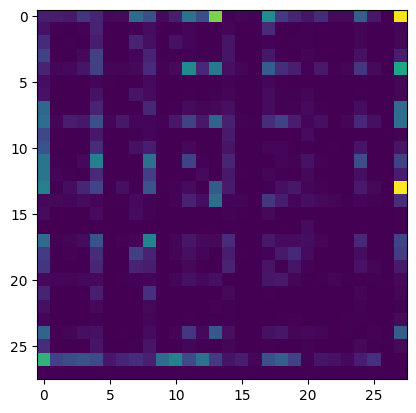

In [20]:
# still pretty ugly vis
plt.imshow(N)

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

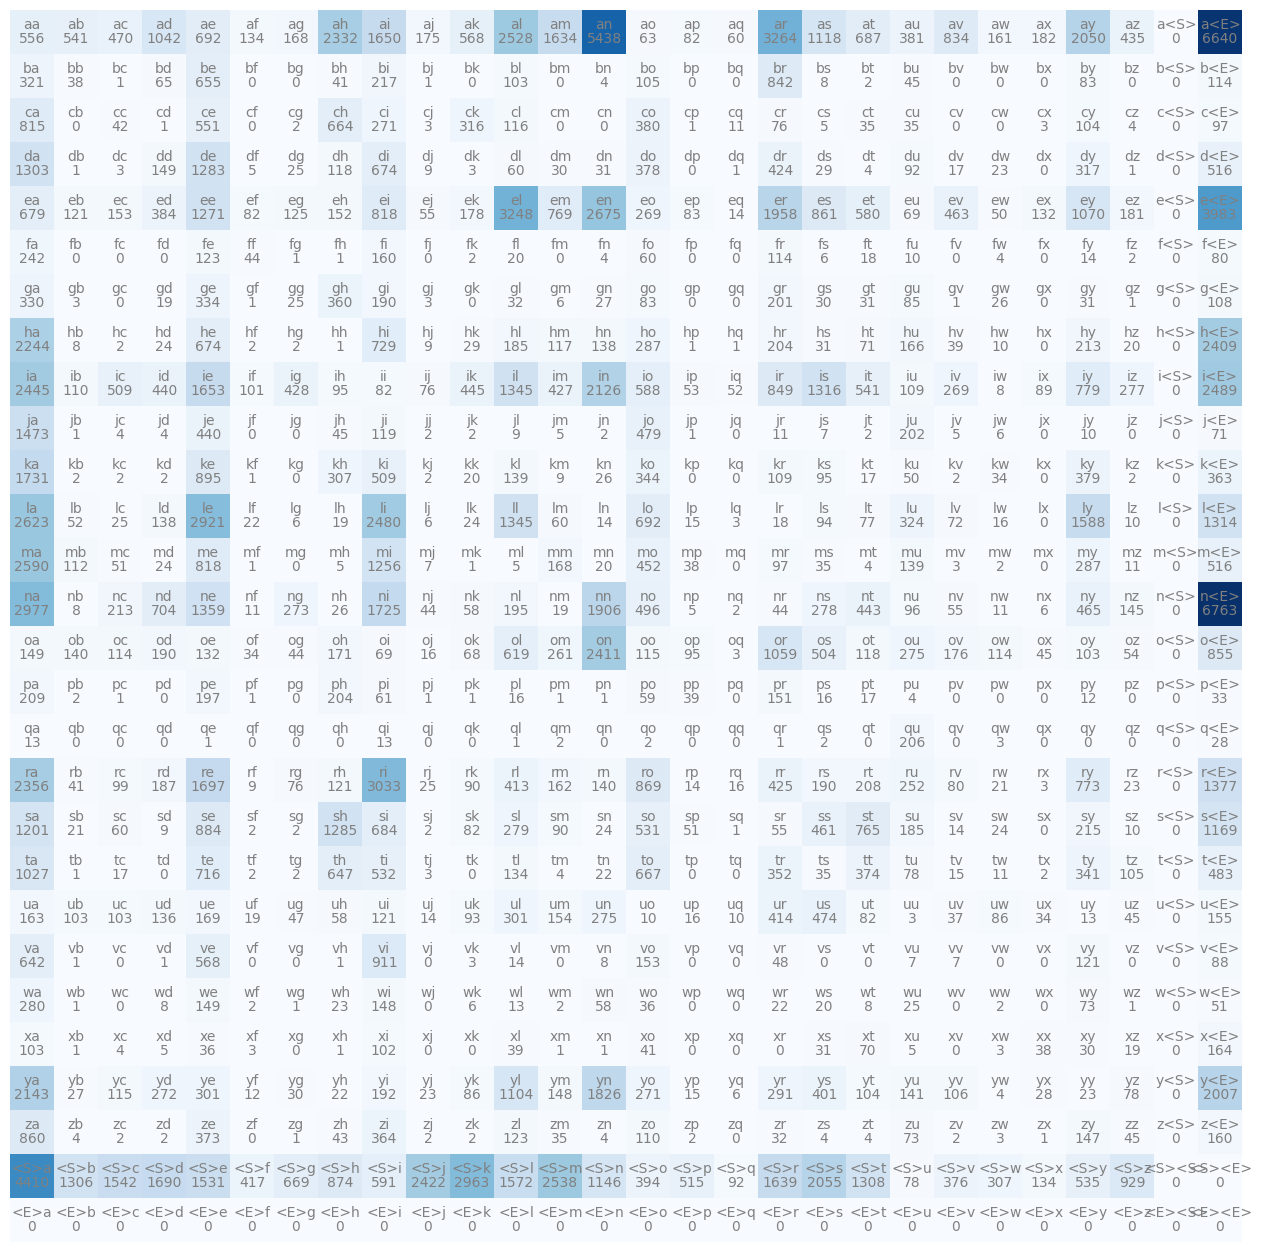

In [21]:
# trying to do better by inversing the stoi array
itos =  {i:s for s, i in stoi.items()}

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(28):
    for j in range(28):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha='center', va='bottom', color='gray')
        plt.text(j, i, N[i, j].item(), ha='center', va='top', color='gray')
plt.axis('off')

In [22]:
# Since no character can lead <S> and no character can follow <E> we can deduplicate them by only using one character that shows start and end
N = torch.zeros((27,27), dtype=torch.int32)

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['<.>'] = 0
itos = {i:s for s, i in stoi.items()}
stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '<.>': 0}

In [23]:
for w in words:
    chs = ['<.>'] + list(w) + ['<.>']
    for ch1, ch2, in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

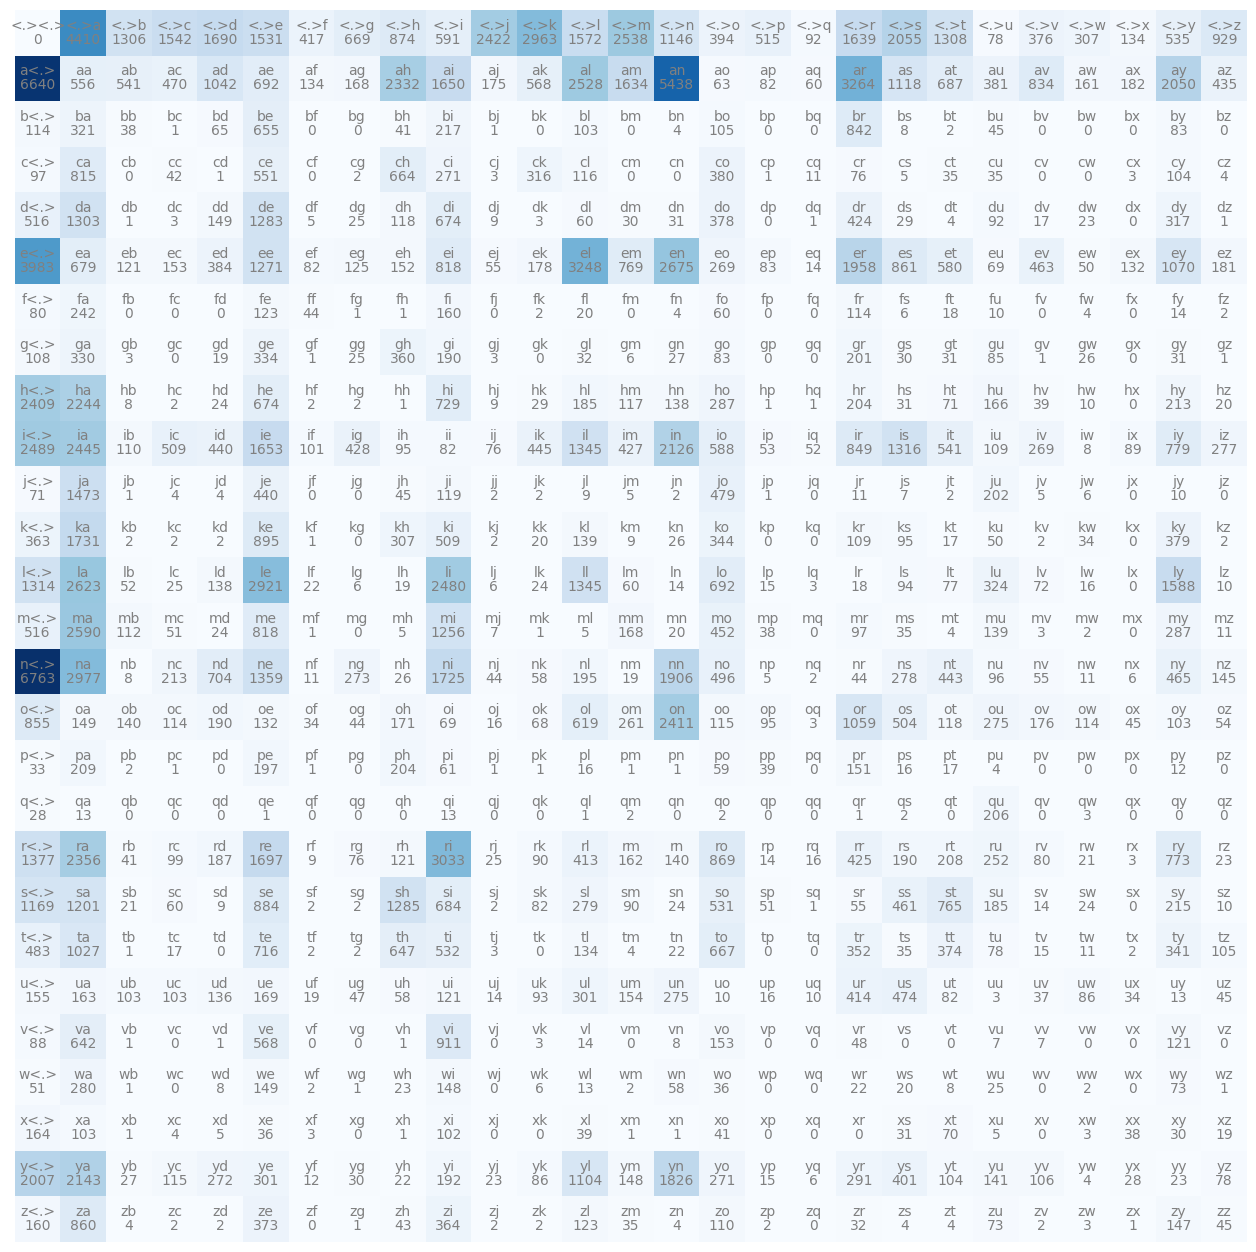

In [24]:
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha='center', va='bottom', color='gray')
        plt.text(j, i, N[i, j].item(), ha='center', va='top', color='gray')
plt.axis('off')

In [25]:
# we are now starting to sample for the first char
N[0].shape
p = N[0].float() # for normalization
p = p / p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

Small sidequest to understand torch generator and multinomial sampling functions

In [26]:
# getting samples from the multinomial distribution via a generator
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator=g)
p = p / p.sum()
p

tensor([0.6064, 0.3033, 0.0903])

In [27]:
torch.multinomial(p, num_samples=20, replacement=True, generator=g)

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1])

Back to the mainquest

In [28]:
# we are now starting to sample for the first char
N[0].shape
p = N[0].float() # for normalization
p = p / p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [29]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
itos[ix]

'c'

In [30]:
# looping through the generation
g = torch.Generator().manual_seed(2147483647)
out = []

for i in range(20):

    ix = 0
    while True:
        p = N[ix].float()
        p = p / p.sum()
        # untrained model below
        #p = torch.ones(27) / 27.0
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
print(''.join(out))

cexze<.>momasurailezitynn<.>konimittain<.>llayn<.>ka<.>da<.>staiyaubrtthrigotai<.>moliellavo<.>ke<.>teda<.>ka<.>emimmsade<.>enkaviyny<.>ftlspihinivenvorhlasu<.>dsor<.>br<.>jol<.>pen<.>aisan<.>ja<.>


Takeaway: bigram models are just so horrible, that Andrej believed he made a mistake implementing this one xD

Going on another sidequest: using the bigrams to find out who of my uni friends has the most commonly constructed name

We have three candidates in the race: Aaron(no way I would bet my money on him), Ayman and Cedric (myself)

In [147]:
def How0815ismyname(names: list, words: str):
    """
    A func that takes a name as input and determines a score and ranking how commonly constructed this name is with respect to the bigrams of the names in the words object.

    Parameters:
    name (str): The list of names to be analyzed
    words (str): The filename of the .txt file holding the names to derive the bigrams from

    Returns:
    probability (double): The bigram model probability to predict exactly the names entered
    """
    words = open(words, 'r').read().splitlines()
    N = torch.zeros((27,27), dtype=torch.double)

    chars = sorted(list(set(''.join(words))))
    stoi = {s:i+1 for i, s in enumerate(chars)}
    stoi['.'] = 0
        
    for w in words:
        chs = ['.'] + list(w) + ['.']
        for ch1, ch2, in zip(chs, chs[1:]):
            ix1 = stoi[ch1]
            ix2 = stoi[ch2]
            N[ix1, ix2] += 1

    for name in names:
        name = name.lower() + '.'
        
        probability = torch.Tensor(1,1).double()
        probability[0,0] = 1.0
        for i, char in enumerate(name):
            ix1 = stoi[char]
            if char == '.':
                break
            ix2 = stoi[name[i + 1]]
            p = N[ix1]
            p = p / p.sum()
            probability[0,0] = probability[0,0] * p[ix2]

        print(f'The probability for the name {name[0].upper() + name[1:-1]}: {probability[0,0].data.item()*100:.10f}%')

In [148]:
names = ['Aaron', 'Ayman', 'Cedric']
How0815ismyname(names=names, words='names.txt')

The probability for the name Aaron: 0.0012127717%
The probability for the name Ayman: 0.0021150835%
The probability for the name Cedric: 0.0000042678%
